# Fly connectome bimodularity
Runs the bimodularity-style experiments on a FlyWire subgraph, using the same 160-node slice as `notebooks/bimodularity_dmitry` (loaded from `output/bimodularity/slice_node_assignments_cycle_seed2_n160.csv`).


In [1]:
import sys
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pathlib import Path
from sklearn.cluster import KMeans
from matplotlib.gridspec import GridSpec

sns.set_context('talk')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlepad'] = 12

cwd = Path.cwd().resolve()
if (cwd / "data").exists() and (cwd / "notebooks").exists():
    repo_root = cwd
elif cwd.name == "notebooks" and (cwd.parent / "data").exists():
    repo_root = cwd.parent
else:
    repo_root = cwd

module_path = repo_root / "notebooks" / "bimodularity_dmitry.py"
assert module_path.exists(), f"Missing module: {module_path}"

module_name = "bimodularity_dmitry_impl"
spec = importlib.util.spec_from_file_location(module_name, module_path)
bi = importlib.util.module_from_spec(spec)
sys.modules[module_name] = bi
assert spec.loader is not None
spec.loader.exec_module(bi)
print("Loaded:", module_path)


Loaded: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\notebooks\bimodularity_dmitry.py


In [2]:
GRAPH_PKL = repo_root / "data" / "preprocessed" / "subgraph.pkl"
SLICE_ASSIGNMENTS_CSV = repo_root / "output" / "bimodularity" / "slice_node_assignments_cycle_seed2_n160.csv"

N_CLUSTERS = 6
N_VECTORS = 6

assert GRAPH_PKL.exists(), f"Missing: {GRAPH_PKL}"
assert SLICE_ASSIGNMENTS_CSV.exists(), f"Missing: {SLICE_ASSIGNMENTS_CSV}"

print("GRAPH_PKL:", GRAPH_PKL)
print("SLICE_ASSIGNMENTS_CSV:", SLICE_ASSIGNMENTS_CSV)
SLICE_ASSIGNMENTS_CSV


GRAPH_PKL: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\data\preprocessed\subgraph.pkl
SLICE_ASSIGNMENTS_CSV: C:\Users\20211927\OneDrive - TU Eindhoven\Documents\GitHub\flywire-connectome-analysis\output\bimodularity\slice_node_assignments_cycle_seed2_n160.csv


WindowsPath('C:/Users/20211927/OneDrive - TU Eindhoven/Documents/GitHub/flywire-connectome-analysis/output/bimodularity/slice_node_assignments_cycle_seed2_n160.csv')

In [3]:
slice_nodes = pd.read_csv(SLICE_ASSIGNMENTS_CSV)["node_id"].astype(int).tolist()

G_full = bi.load_flywire_subgraph_pickle(GRAPH_PKL)
G = G_full.subgraph(slice_nodes).copy()
nodes = list(G.nodes())
node_list = pd.Index(nodes)
n = len(nodes)

adj = bi.adjacency_from_digraph(G, nodes, weight="weight")

print(f"Slice nodes requested: {len(slice_nodes)}; present in graph: {n}")
print(f"Edges kept: {G.number_of_edges():,}; total weight: {float(adj.sum()):,.0f}")
adj


Slice nodes requested: 160; present in graph: 160
Edges kept: 6,924; total weight: 361,787


array([[  0.,   0.,   0., ...,   0.,  30.,   0.],
       [  6.,   0.,   0., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ..., 182.,   0.,   0.],
       ...,
       [  0.,   0., 128., ...,   0.,   0.,   0.],
       [  0.,   0.,   0., ...,   0.,   0.,   0.],
       [133.,   0.,   0., ...,   0.,   0.,   0.]], shape=(160, 160))

## Preprocess graph (reindex, optionally filter)
- The adjacency is already built on the Dmitry slice nodes.
- Compute per-node strength (incoming + outgoing weights) for inspection.


In [4]:
out_strength = pd.Series(adj.sum(axis=1), index=node_list)
in_strength = pd.Series(adj.sum(axis=0), index=node_list)
strength = out_strength.add(in_strength, fill_value=0)

print(f"Nodes kept: {n}, edges kept: {G.number_of_edges():,}, total weight: {float(adj.sum()):,.0f}")
strength.sort_values(ascending=False).head(10)


Nodes kept: 160, edges kept: 6,924, total weight: 361,787


720575940614956072    10961.0
720575940632795532    10867.0
720575940623000858    10722.0
720575940635945919    10593.0
720575940609282825    10229.0
720575940634545890     9759.0
720575940618757666     9452.0
720575940640803200     9177.0
720575940613804259     9018.0
720575940638128474     8742.0
dtype: float64

## Helper functions (directed modularity, SVD, bicommunities)
These replicate the logic of the original bimodularity utilities inside the notebook.


In [5]:
from typing import Tuple

def modularity_matrix(A: np.ndarray, null_model: str = 'outin') -> np.ndarray:
    """Directed modularity matrix with out*in null model."""
    kout = A.sum(axis=1, keepdims=True)
    kin = A.sum(axis=0, keepdims=True)
    m = A.sum()
    if m == 0:
        return np.zeros_like(A)
    if null_model == 'outin':
        P = kout @ kin / m
    else:
        raise ValueError("Only 'outin' null model supported here")
    return A - P

def sorted_svd(B: np.ndarray):
    U, S, Vt = np.linalg.svd(B, full_matrices=False)
    order = np.argsort(S)[::-1]
    return U[:, order], S[order], Vt[order].T

def edge_bicommunities(B: np.ndarray, U: np.ndarray, V: np.ndarray, n_vectors: int = 4,
                       n_clusters: int = 5, random_state: int = 0):
    """Cluster edges using top singular vectors (sending=U, receiving=V)."""
    u_emb = U[:, :n_vectors] * np.sqrt(np.maximum(0, np.abs(B)).mean())
    v_emb = V[:, :n_vectors] * np.sqrt(np.maximum(0, np.abs(B)).mean())
    send_idx, recv_idx = np.nonzero(B)
    feats = np.hstack([u_emb[send_idx], v_emb[recv_idx]])
    km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=random_state)
    labels = km.fit_predict(feats)
    return send_idx, recv_idx, labels, km

def get_node_communities(edge_u, edge_v, edge_labels, n_nodes: int, method: str = 'majority'):
    """Infer sending/receiving communities per node from edge labels."""
    send_comm = np.zeros(n_nodes, dtype=int)
    recv_comm = np.zeros(n_nodes, dtype=int)
    for node in range(n_nodes):
        outgoing = edge_labels[edge_u == node]
        incoming = edge_labels[edge_v == node]
        if len(outgoing):
            send_comm[node] = np.bincount(outgoing).argmax()
        if len(incoming):
            recv_comm[node] = np.bincount(incoming).argmax()
    return send_comm, recv_comm

def bimodularity_index(A: np.ndarray, send_comm: np.ndarray, recv_comm: np.ndarray) -> np.ndarray:
    """Simple bimodularity score: fraction of weight inside a node's (send,recv) block."""
    m = A.sum()
    n = len(send_comm)
    scores = np.zeros(n)
    for i in range(n):
        mask_out = send_comm == send_comm[i]
        mask_in = recv_comm == recv_comm[i]
        block_weight = A[np.ix_(mask_out, mask_in)].sum()
        if m > 0:
            scores[i] = block_weight / m
    return scores


## Spectrum and leading singular vectors
We inspect the singular values of the directed modularity matrix and visualize the leading sending/receiving components.


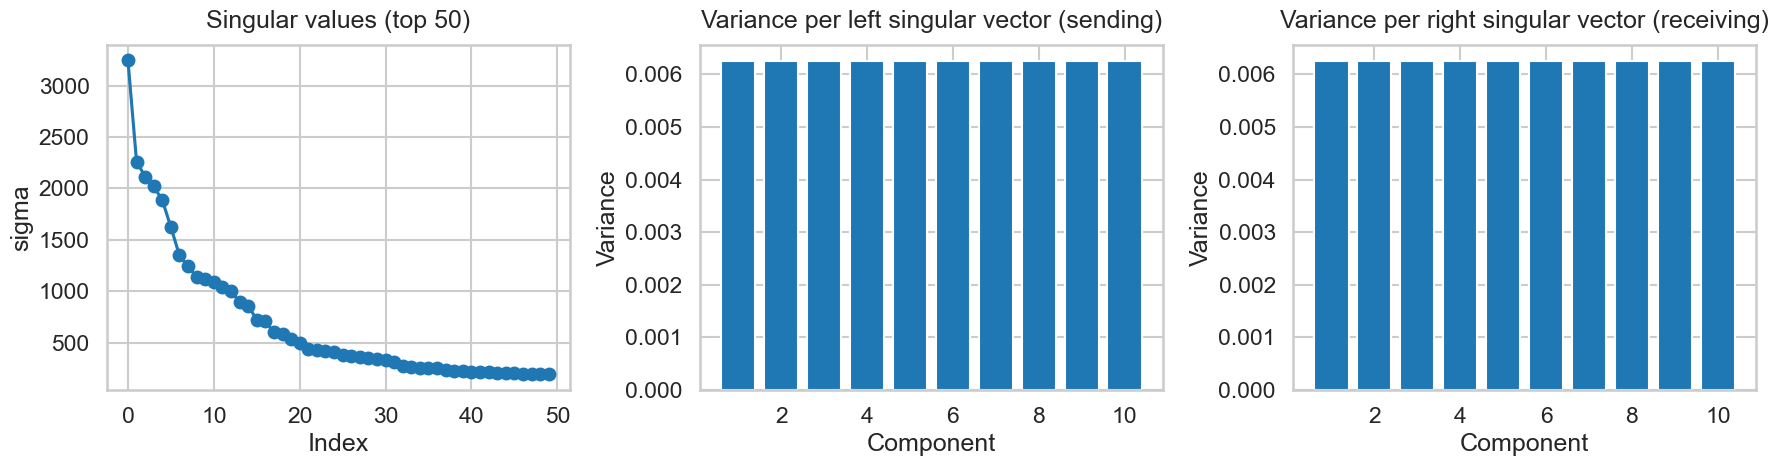

In [6]:
B = modularity_matrix(adj, null_model='outin')
U, S, V = sorted_svd(B)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(S[:50], marker='o')
axes[0].set_title('Singular values (top 50)')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('sigma')

axes[1].bar(range(1, 11), U[:, :10].var(axis=0))
axes[1].set_title('Variance per left singular vector (sending)')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Variance')

axes[2].bar(range(1, 11), V[:, :10].var(axis=0))
axes[2].set_title('Variance per right singular vector (receiving)')
axes[2].set_xlabel('Component')
axes[2].set_ylabel('Variance')
plt.tight_layout()
plt.show()


## Edge bicommunities via spectral clustering
We embed each observed edge using top singular vectors, cluster with k-means, then map clusters back to sending/receiving nodes.


In [7]:
edge_u, edge_v, edge_labels, km = edge_bicommunities(B, U, V, n_vectors=N_VECTORS, n_clusters=N_CLUSTERS, random_state=7)
send_comm, recv_comm = get_node_communities(edge_u, edge_v, edge_labels, n_nodes=n)

print('Edge clusters:', np.bincount(edge_labels))
print('Sending communities:', np.bincount(send_comm))
print('Receiving communities:', np.bincount(recv_comm))


Edge clusters: [  467  3565 19995   937   159   158]
Sending communities: [  4   0 155   0   0   1]
Receiving communities: [  1  23 129   6   1]


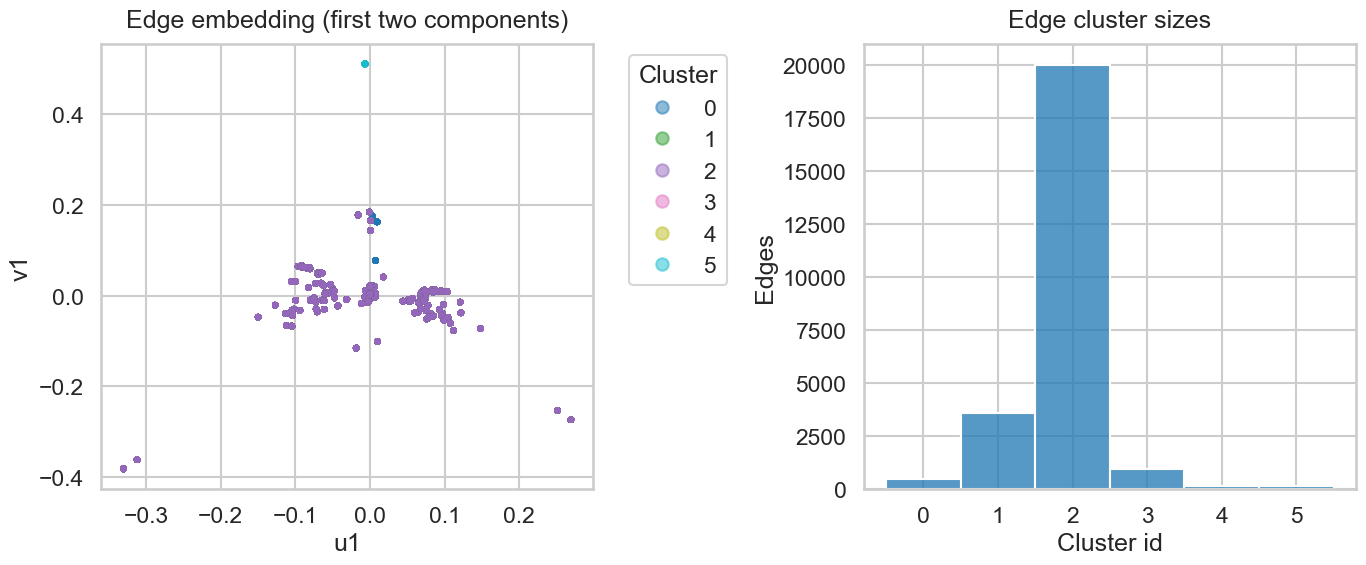

In [8]:
edge_feats = np.hstack([U[edge_u, :N_VECTORS], V[edge_v, :N_VECTORS]])
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter = axes[0].scatter(edge_feats[:,0], edge_feats[:,1], c=edge_labels, cmap='tab10', alpha=0.5, s=10)
axes[0].set_title('Edge embedding (first two components)')
axes[0].set_xlabel('u1')
axes[0].set_ylabel('v1')
axes[0].legend(*scatter.legend_elements(), title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.histplot(edge_labels, ax=axes[1], bins=N_CLUSTERS, discrete=True)
axes[1].set_title('Edge cluster sizes')
axes[1].set_xlabel('Cluster id')
axes[1].set_ylabel('Edges')
plt.tight_layout()
plt.show()


## Bimodularity scores and adjacency structure
- Compute a simple bimodularity index per node (share of total weight in its sending/receiving block).
- Reorder adjacency by sending and receiving communities and visualize block structure.


In [9]:
bimod_scores = bimodularity_index(adj, send_comm, recv_comm)
score_df = pd.DataFrame({
    'node': node_list,
    'send_comm': send_comm,
    'recv_comm': recv_comm,
    'bimod_score': bimod_scores
}).sort_values('bimod_score', ascending=False)
score_df.head(10)


,node,send_comm,recv_comm,bimod_score
0,720575940628695043,2,2,0.686628
1,720575940628455942,2,2,0.686628
5,720575940627927573,2,2,0.686628
4,720575940632403986,2,2,0.686628
6,720575940624155672,2,2,0.686628
14,720575940623201833,2,2,0.686628
9,720575940617537570,2,2,0.686628
8,720575940633483807,2,2,0.686628
15,720575940631586858,2,2,0.686628
22,720575940626143806,2,2,0.686628


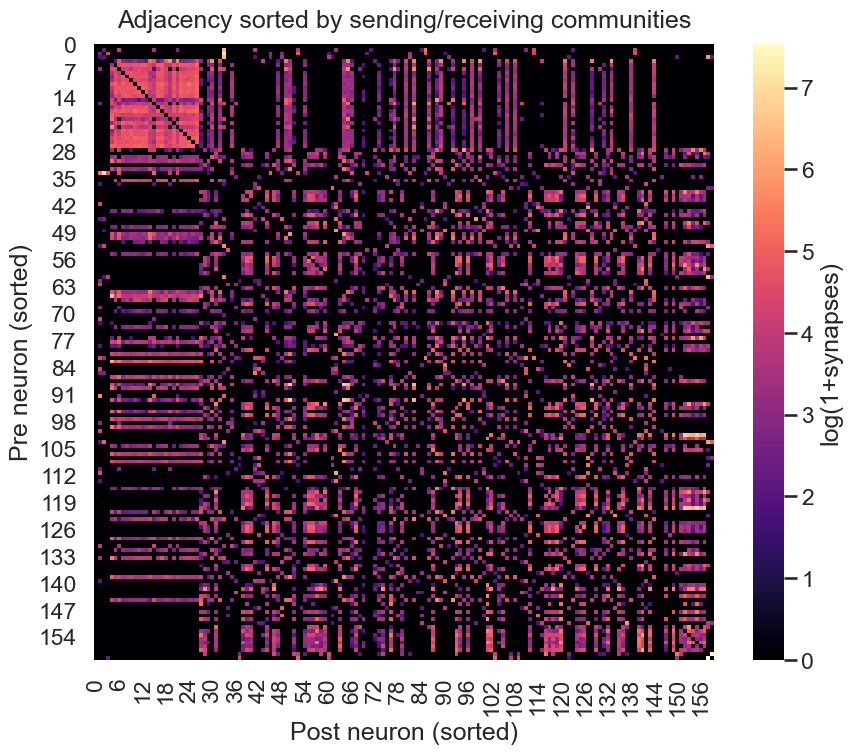

In [10]:
order = np.argsort(send_comm * 100 + recv_comm)
A_sorted = adj[np.ix_(order, order)]

plt.figure(figsize=(10, 8))
sns.heatmap(np.log1p(A_sorted), cmap='magma', cbar_kws={'label': 'log(1+synapses)'})
plt.title('Adjacency sorted by sending/receiving communities')
plt.xlabel('Post neuron (sorted)')
plt.ylabel('Pre neuron (sorted)')
plt.show()


## Network view of top communities
Visualize the induced subgraph of the largest sending community, colored by receiving community.


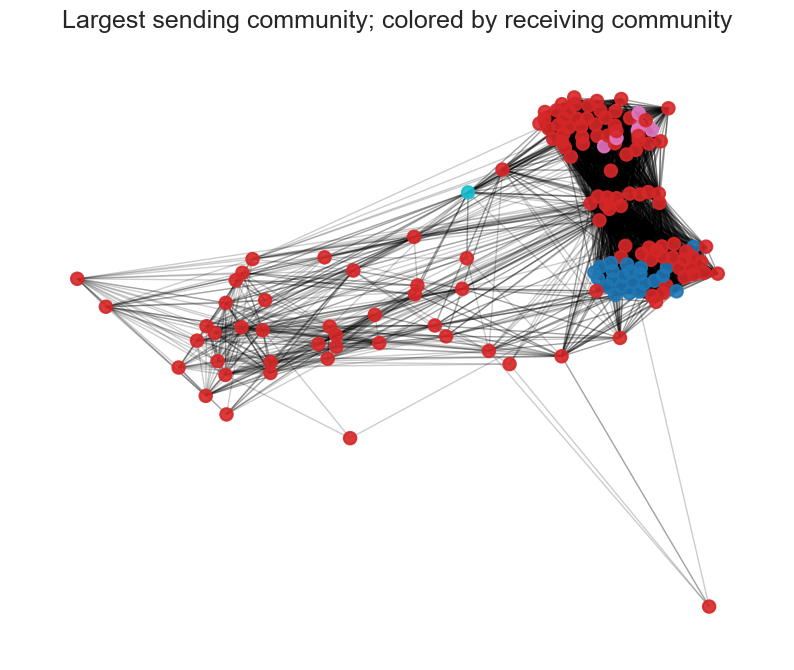

In [11]:
largest_send = np.bincount(send_comm).argmax()
mask_send = send_comm == largest_send
sub_idx = np.where(mask_send)[0]
sub_nodes = node_list[sub_idx]
G = nx.from_numpy_array(adj[np.ix_(sub_idx, sub_idx)], create_using=nx.DiGraph)
pos = nx.spring_layout(G, weight='weight', seed=3, k=0.6)
node_colors = recv_comm[sub_idx]
plt.figure(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_size=80, node_color=node_colors, cmap='tab10', alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.2, arrows=False)
plt.title('Largest sending community; colored by receiving community')
plt.axis('off')
plt.show()


## Notes
- To change the slice, point `SLICE_ASSIGNMENTS_CSV` at a different `slice_node_assignments_*.csv`.
- Adjust `N_CLUSTERS`/`N_VECTORS` to explore different bicommunity granularities.
- Swap the null model in `modularity_matrix` if you want alternative baselines.
- Export cluster assignments with `score_df.to_csv(...)` for downstream analyses or Gephi.
